# The Setup

In [1]:
import numpy as np
import pandas as pd

In [2]:
df = pd.read_csv('heart.csv')
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


Hehe! No missing values

In [4]:
y = df['target']
X = df.drop(columns=['target'])

# The Predictor

In [26]:
X = df[['age']]
y = df[['thalach']]

In [27]:
# split into train test
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [28]:
# train lin reg model
from sklearn.linear_model import LinearRegression 
lin_model = LinearRegression()
lin_model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


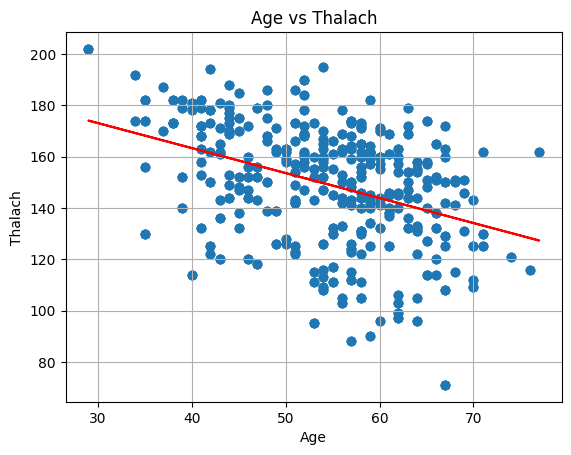

Thalach = Age * [[-0.97472057]] + [202.34392402]


In [29]:
# scatter plot of age vs thalach
import matplotlib.pyplot as plt 
plt.scatter(X, y)
plt.plot(X, lin_model.predict(X), color='red')
plt.xlabel('Age')
plt.ylabel('Thalach')
plt.title('Age vs Thalach')
plt.grid()
plt.show()
print(f'Thalach = Age * {lin_model.coef_} + {lin_model.intercept_}')

# The Classifier

In [30]:
X2 = df[['age', 'sex', 'cp', 'trestbps', 'chol']]
y2 = df[['target']]

In [31]:
X_train2, X_test2, y_train2, y_test2 = train_test_split(X2, y2, test_size=0.2, random_state=42)

In [33]:
# logistic regression
from sklearn.linear_model import LogisticRegression 
log_model = LogisticRegression()
log_model.fit(X_train2, y_train2)

c:\Users\super\VS_CODE\.techai\Lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


# The Judge

In [34]:
y_pred = log_model.predict(X_test2)

In [35]:
# f1 score
from sklearn.metrics import f1_score 
f1 = f1_score(y_test2, y_pred)
print(f'F1 Score: {f1}')

F1 Score: 0.7902439024390244


F1 Score, intuitively, is ...

In [36]:
# roc-auc score
from sklearn.metrics import roc_auc_score 
roc = roc_auc_score(y_test2, y_pred)
print(f'ROC-AUC Score: {roc}')

ROC-AUC Score: 0.7902627070245575


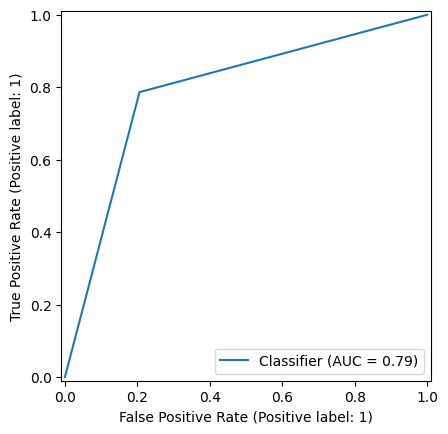

In [37]:
# plotting roc curve
from sklearn.metrics import RocCurveDisplay 
RocCurveDisplay.from_predictions(y_test2, y_pred)
plt.show()

# Bonus Challenge

In [38]:
X3 = df.drop(columns=['target'])
y3 = df['target']

In [ ]:
X_train3, X_test3, y_train3, y_test3 = train_test_split(X3, y3, test_size=0.2, random_state=42)